In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save model
import joblib

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.shape

(6607, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Handling Missing Values

df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0]
)

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

In [11]:
df.isnull().sum().sum()

np.int64(0)

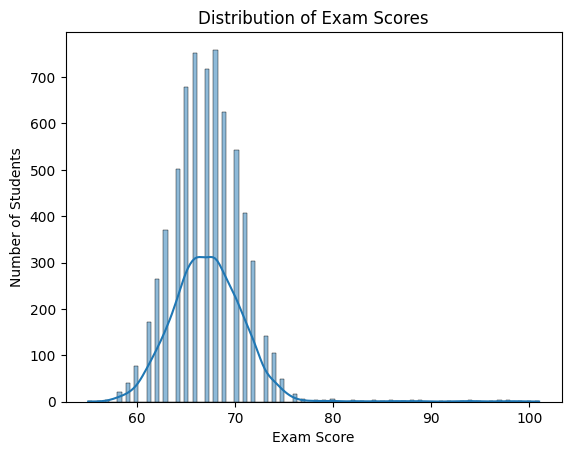

In [12]:
plt.figure()
sns.histplot(df['Exam_Score'], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

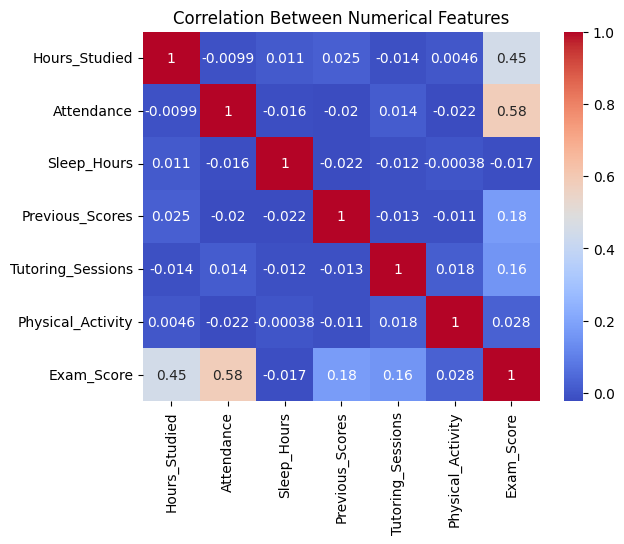

In [14]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Features")
plt.show()

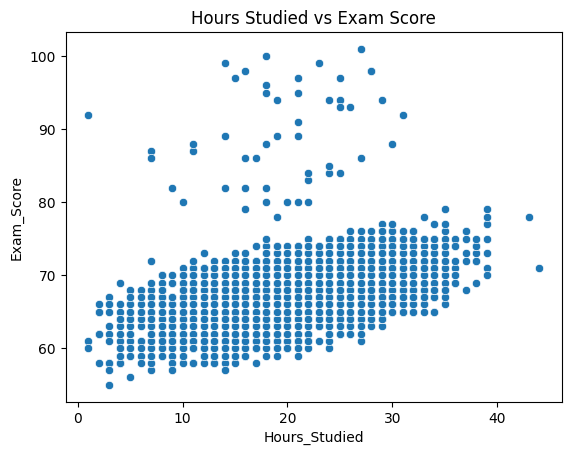

In [20]:
plt.figure()

sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Hours Studied vs Exam Score")

plt.show()

# **Feature Engineering**

The target variable is Exam_Score because the goal is to predict student performance. All educational and environmental factors are included as they may affect academic success. Categorical data is converted into numerical values using one-hot encoding so the machine learning model can process it.

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False


In [22]:
# Splitting Features and Target

X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score']

In [23]:
# Splitting Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Standardization

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

I trained and compared four regression models to find which one performs best for predicting exam scores:
*   Linear Regression
*   Stochastic Gradient Descent Regression
*   Decision Tree Regression
*   Random Forest Regression

In [28]:
# Linear Regression Model

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression MSE: 3.2560199870428943
Linear Regression R2: 0.7696495724907312


In [30]:
# Stochastic Gradient Descent Regression Model

sgd = SGDRegressor(max_iter=1000, learning_rate="constant", eta0=0.001, random_state=42)
sgd.fit(X_train_scaled, y_train)

y_pred_sgd = sgd.predict(X_test_scaled)

print("SGD Regression MSE:", mean_squared_error(y_test, y_pred_sgd))
print("SGD Regression R2:", r2_score(y_test, y_pred_sgd))

SGD Regression MSE: 3.27704267358845
SGD Regression R2: 0.76816230126622


In [31]:
# Decision Tree Model

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree MSE: 6.3079793483322755
Decision Tree R2: 0.5537356203615846


In [35]:
# Random Forest Model

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest MSE: 5.677031037992365
Random Forest R2: 0.5983726967927541


In [37]:
loss_model = SGDRegressor(max_iter=1, learning_rate="constant", eta0=0.001, warm_start=True, random_state=42)

train_losses = []
test_losses = []


for epoch in range(100):
    loss_model.fit(X_train_scaled, y_train)

    train_pred = loss_model.predict(X_train_scaled)
    test_pred = loss_model.predict(X_test_scaled)


    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

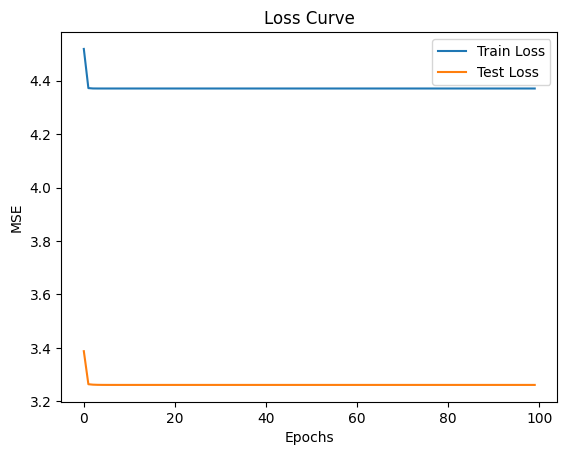

In [38]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

In [39]:
# Model Comparison

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "SGD Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_sgd),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf)
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_sgd),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],

    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_sgd),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]

})

results

,Model,MSE,MAE,R2
0,Linear Regression,3.256020,0.452392,0.769650
1,SGD Regression,3.277043,0.453386,0.768162
2,Decision Tree,6.307979,1.599790,0.553736
3,Random Forest,5.677031,1.439654,0.598373


In [40]:
# Feature importance analysis

feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": lr.coef_})
feature_importance["Absolute Importance"] = abs(feature_importance["Importance"])
feature_importance = feature_importance.sort_values(by="Absolute Importance", ascending=False)
feature_importance.head(10)


,Feature,Importance,Absolute Importance
1,Attendance,2.290405,2.290405
0,Hours_Studied,1.756881,1.756881
8,Access_to_Resources_Low,-0.838966,0.838966
6,Parental_Involvement_Low,-0.804623,0.804623
3,Previous_Scores,0.705908,0.705908
4,Tutoring_Sessions,0.626224,0.626224
14,Family_Income_Low,-0.544276,0.544276
7,Parental_Involvement_Medium,-0.534638,0.534638
20,Peer_Influence_Positive,0.516698,0.516698
9,Access_to_Resources_Medium,-0.515775,0.515775


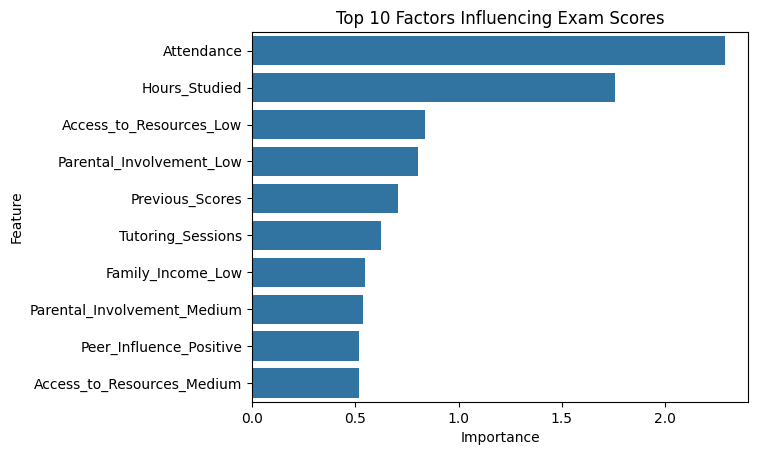

In [44]:
plt.figure()

sns.barplot(data=feature_importance.head(10), x="Absolute Importance", y="Feature")

plt.title("Top 10 Factors Influencing Exam Scores")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

# **Feature Importance Interpretation**

The results show that attendance and study hours are the most important factors affecting exam scores. Other factors like resources, parental involvement, previous scores, and tutoring also contribute to student performance.

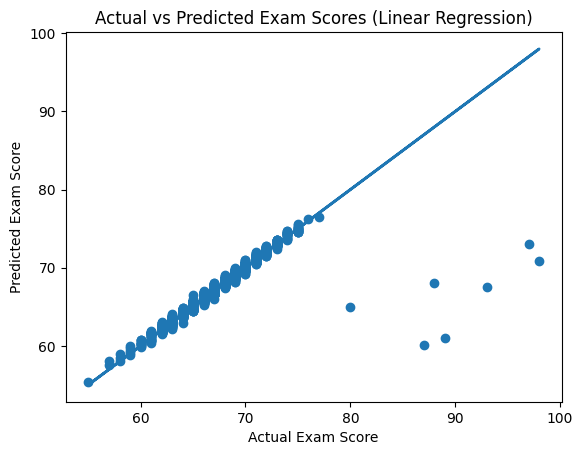

In [47]:
# Scatter plot with regression line

plt.figure()

plt.scatter(y_test, y_pred_lr)
plt.plot(y_test, y_test, linewidth=2)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores (Linear Regression)")

plt.show()


# **Linear Regression Visualization Interpretation**

The scatter plot shows a positive relationship between actual and predicted exam scores. Most points are close to the line, showing that the model predicts scores well, while some differences show prediction errors.

In [57]:
# Select one student record from the test dataset

record_index = 2
student_data = X_test.iloc[[record_index]]
actual_score = y_test.iloc[record_index]

print("Selected Student Information:")
print(student_data)

print("\nActual Exam Score:", actual_score)

Selected Student Information:
      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
3442             21          91            6               53   

      Tutoring_Sessions  Physical_Activity  Parental_Involvement_Low  \
3442                  1                  3                     False   

      Parental_Involvement_Medium  Access_to_Resources_Low  \
3442                        False                    False   

      Access_to_Resources_Medium  ...  Teacher_Quality_Medium  \
3442                        True  ...                    True   

      School_Type_Public  Peer_Influence_Neutral  Peer_Influence_Positive  \
3442                True                   False                     True   

      Learning_Disabilities_Yes  Parental_Education_Level_High School  \
3442                      False                                 False   

      Parental_Education_Level_Postgraduate  Distance_from_Home_Moderate  \
3442                                   True                 

In [58]:
# Predict the selected student's exam score

student_scaled = scaler.transform(student_data)
predicted_score = lr.predict(student_scaled)[0]

print(f"\nActual 'Exam Score': {actual_score}")
print(f"Predicted 'Exam Score' (Linear Regression): {predicted_score:.2f}")
print(f"Difference between actual and predicted score: {abs(actual_score - predicted_score):.2f}")



Actual 'Exam Score': 71
Predicted 'Exam Score' (Linear Regression): 71.53
Difference between actual and predicted score: 0.53


In [59]:
# Save the best model
joblib.dump(lr, "best_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save the feature names
joblib.dump(X.columns.tolist(), "features.pkl")

print("Model saved successfully!")

Model saved successfully!


Creating **a Prediction Function** which load the saved model and predict a student's exam score.

In [60]:
# Function to predict exam score

def predict_exam_score(student_data):

    # Scale the input data
    student_scaled = scaler.transform(student_data)

    # Predict the exam score
    prediction = lr.predict(student_scaled)

    return prediction[0]

In [61]:
predicted = predict_exam_score(student_data)

print("Predicted Exam Score:", round(predicted, 2))

Predicted Exam Score: 71.53
